# Analise exploratotia vendas

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/vendas.csv")

**Entendendo os dados:**

In [22]:
df.head(5)

,ID_Pedido,Data,Cliente,Cidade,Estado,Categoria,Produto,Quantidade,Preco_Unitario,Desconto,Vendas,Lucro,Pagamento
0,1001,2025-01-03,Ana,Recife,PE,Eletrônicos,Mouse,2,80,0.10,144,44,Cartão
1,1002,2025-01-05,Carlos,Petrolina,PE,Informática,Teclado,1,150,0.00,150,50,PIX
2,1003,2025-01-08,João,Juazeiro,BA,Eletrônicos,Fone de Ouvido,3,120,0.05,342,102,Boleto
3,1004,2025-01-10,Maria,Recife,PE,Móveis,Cadeira,2,350,0.10,630,180,Cartão
4,1005,2025-01-12,Lucas,Fortaleza,CE,Informática,Monitor,1,900,0.15,765,165,PIX


In [23]:
#Quantas linhas e colunas temos:
df.shape

(10, 13)

In [24]:
#Tipos de dados de cada coluna
df.dtypes

,0
ID_Pedido,int64
Data,object
Cliente,object
Cidade,object
Estado,object
Categoria,object
Produto,object
Quantidade,int64
Preco_Unitario,int64
Desconto,float64


Precis afazer tratamento em Data e Lucro

In [25]:
#Convertando Data
df["Data"]= pd.to_datetime(df["Data"])

In [26]:
#Converter Lucro

In [27]:
df["Lucro"]= df["Lucro"].astype(float)

In [28]:
#Mostrando novamento os tipos de dados que estou lidando
df.dtypes

,0
ID_Pedido,int64
Data,datetime64[ns]
Cliente,object
Cidade,object
Estado,object
Categoria,object
Produto,object
Quantidade,int64
Preco_Unitario,int64
Desconto,float64


**Analise dos lucros**

In [29]:
df.head(1)

,ID_Pedido,Data,Cliente,Cidade,Estado,Categoria,Produto,Quantidade,Preco_Unitario,Desconto,Vendas,Lucro,Pagamento
0,1001,2025-01-03,Ana,Recife,PE,Eletrônicos,Mouse,2,80,0.1,144,44.0,Cartão




**Faturamento total: é a soma de todas as vendas?**

In [30]:
df["Vendas"].sum()

np.int64(7436)

Ou seja o nosso Faturamento total foi: 7.436$

**Lucro total: é o quanto a empresa ganhou depois de descontar os custos?**


In [33]:
df["Lucro"].sum()

np.float64(1726.0)

Ou seja, o lucro total foi: 1.726$

**Qual categoria vendeu mais?**

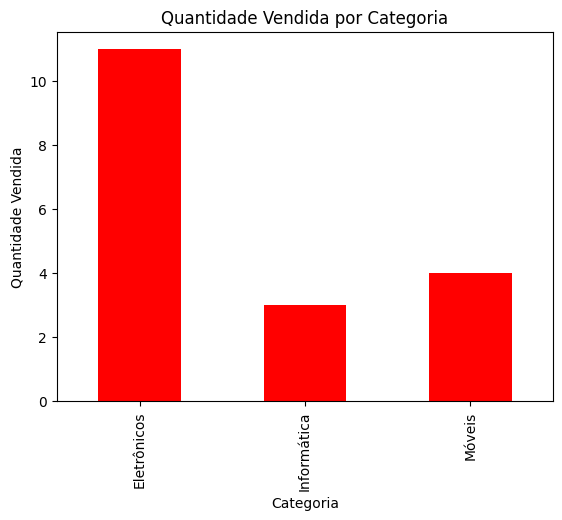

In [105]:

df.groupby("Categoria")["Quantidade"].sum().plot.bar(
    title="Quantidade Vendida por Categoria",
    color="red"
)

plt.xlabel("Categoria")
plt.ylabel("Quantidade Vendida")
plt.show()

**Qual produto teve o maior faturamento?**

In [47]:
df.loc[df["Vendas"].idxmax()]

,7
ID_Pedido,1008
Data,2025-01-20 00:00:00
Cliente,Sofia
Cidade,Caruaru
Estado,PE
Categoria,Informática
Produto,Notebook
Quantidade,1
Preco_Unitario,3200
Desconto,0.1


In [92]:
#Quam teve o maior lucro
df.loc[df["Lucro"].idxmax()]

,7
ID_Pedido,1008
Data,2025-01-20 00:00:00
Cliente,Sofia
Cidade,Caruaru
Estado,PE
Categoria,Informática
Produto,Notebook
Quantidade,1
Preco_Unitario,3200
Desconto,0.1


Pu seja, o produto com o valor mais alto vendido foi com o valor de 2880$ e o
 luvro da soja foui 480$

**Qual estado gerou mais vendas?**

In [53]:
df.groupby("Estado")["Vendas"].value_counts()

Estado  Vendas
BA      342       1
        665       1
CE      400       1
        765       1
PE      144       1
        150       1
        320       1
        630       1
        1140      1
        2880      1
Name: count, dtype: int64

In [57]:
#Contar produtos lucro por estado (Bahia)
df.loc[df["Estado"]=="BA", "Vendas"].sum()

np.int64(1007)

In [58]:
#Contar produtos lucro por estado (Ceara)
df.loc[df["Estado"]=="CE", "Vendas"].sum()

np.int64(1165)

In [59]:
#Contar produtos lucro por estado (PE)
df.loc[df["Estado"]=="PE", "Vendas"].sum()

np.int64(5264)

Ou seja:

01 - Pernambuco , 5264$

02 - Ceara, 1165$

03 - Bahia - 1007$

Text(0, 0.5, 'Vendas')

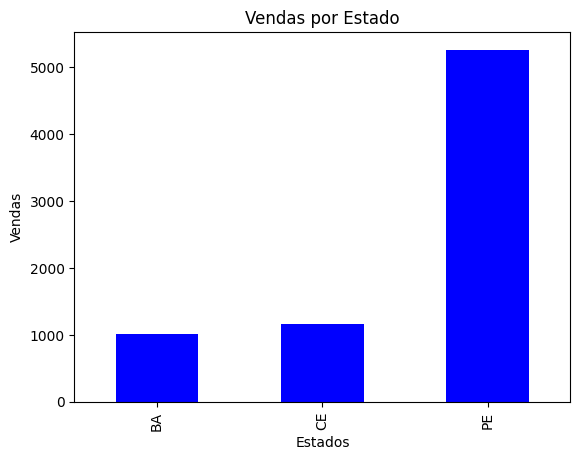

In [63]:
#Agrupar duas variavies
df.groupby("Estado")["Vendas"].sum().plot.bar(
    title="Vendas por Estado",
    color="blue"
)
plt.xlabel("Estados")
plt.ylabel("Vendas")


#Lembra sempre
'''sum()
mean()
value_counts()'''

Qual cliente comprou mais?

In [67]:
df.loc[df["Vendas"].idxmax()]

,7
ID_Pedido,1008
Data,2025-01-20 00:00:00
Cliente,Sofia
Cidade,Caruaru
Estado,PE
Categoria,Informática
Produto,Notebook
Quantidade,1
Preco_Unitario,3200
Desconto,0.1


Ou seja, o clinte que compreu mais foi a sofia de PE, com o valor de 2880$

**O crinte que Compreu menos?**

In [71]:
df.loc[df["Vendas"].idxmin()]

,0
ID_Pedido,1001
Data,2025-01-03 00:00:00
Cliente,Ana
Cidade,Recife
Estado,PE
Categoria,Eletrônicos
Produto,Mouse
Quantidade,2
Preco_Unitario,80
Desconto,0.1


Ou seja, o clinte que compreu menos foi a Ana de PE, valor de 144$

**Qual forma de pagamento foi a mais utilizada?**

In [86]:
df["Pagamento"].value_counts()

,count
Pagamento,
Cartão,4
PIX,3
Boleto,3


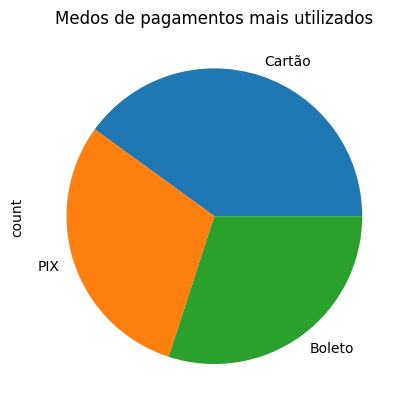

In [85]:
df["Pagamento"].value_counts().plot.pie(
    title="Medos de pagamentos mais utilizados"
);



In [87]:
df.head(1)

,ID_Pedido,Data,Cliente,Cidade,Estado,Categoria,Produto,Quantidade,Preco_Unitario,Desconto,Vendas,Lucro,Pagamento
0,1001,2025-01-03,Ana,Recife,PE,Eletrônicos,Mouse,2,80,0.1,144,44.0,Cartão


In [90]:
df.describe()

,ID_Pedido,Data,Quantidade,Preco_Unitario,Desconto,Vendas,Lucro
count,10.00000,10,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1005.50000,2025-01-13 19:12:00,1.800000,703.000000,0.080000,743.600000,172.600000
min,1001.00000,2025-01-03 00:00:00,1.000000,80.000000,0.000000,144.000000,44.000000
25%,1003.25000,2025-01-08 12:00:00,1.000000,127.500000,0.050000,325.500000,85.500000
50%,1005.50000,2025-01-13 12:00:00,1.500000,300.000000,0.075000,515.000000,142.500000
75%,1007.75000,2025-01-19 12:00:00,2.000000,850.000000,0.100000,740.000000,176.250000
max,1010.00000,2025-01-25 00:00:00,4.000000,3200.000000,0.200000,2880.000000,480.000000
std,3.02765,NaN,1.032796,958.738175,0.063246,810.455318,137.672074


Min= 114$

mediana = 515$

Max = 2880

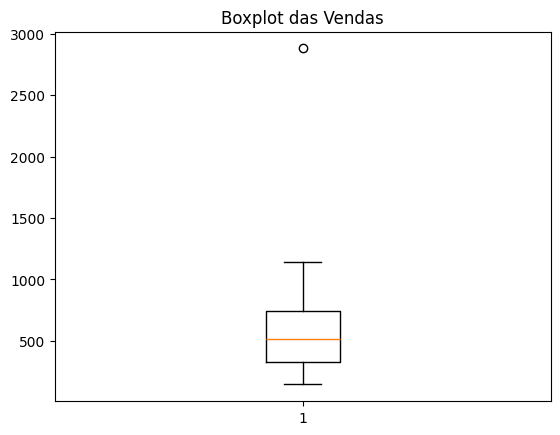

In [99]:
#Criando um grafico de boxplo

plt.boxplot(df["Vendas"])
plt.title("Boxplot das Vendas")
plt.savefig("Boxplot das Vendas.png")
plt.show()

#**Conclusão da Análise Exploratória**

Após a análise dos dados de vendas, foi possível identificar algumas informações importantes:

O faturamento total da empresa foi de R$ 7.436,00, enquanto o lucro total foi de R$ 1.726,00.

A categoria Eletrônicos foi a que apresentou a maior quantidade de vendas, indicando maior procura pelos clientes.

Os produtos mais vendidos são os eletornicos com 11 unidades, informatica com 3 e eletrodomesticos 4.

O produto de maior faturamento foi o Notebook, vendido para a cliente Sofia, totalizando R$ 2.880,00 em uma única venda.

O estado de Pernambuco (PE) foi responsável pelo maior faturamento, com R$ 5.264,00, seguido por Ceará (CE) e Bahia (BA).

OBS:O produto mais vendido e o menos vendido foram em (PE).

A forma de pagamento mais utilizada foi Cartão (ou a que apareceu com maior frequência ).

O boxplot da coluna Vendas indica a presença de valores altos em relação às demais vendas. Esses valores podem ser considerados possíveis outliers, porém, como correspondem à venda de notebooks, eles parecem representar vendas reais e não erros de cadastro.
